### Simple Linear Regression

In [1]:
# =============================
# Step 1: Import libraries
# =============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")


In [29]:
df= pd.read_csv("house_price_data.csv")

In [30]:
df.head()

,Size,Price
0,1360.0,201675.0
1,1794.0,273038.0
2,1630.0,248164.0
3,1595.0,220886.0
4,2138.0,320780.0


In [31]:
df.shape

(201, 2)

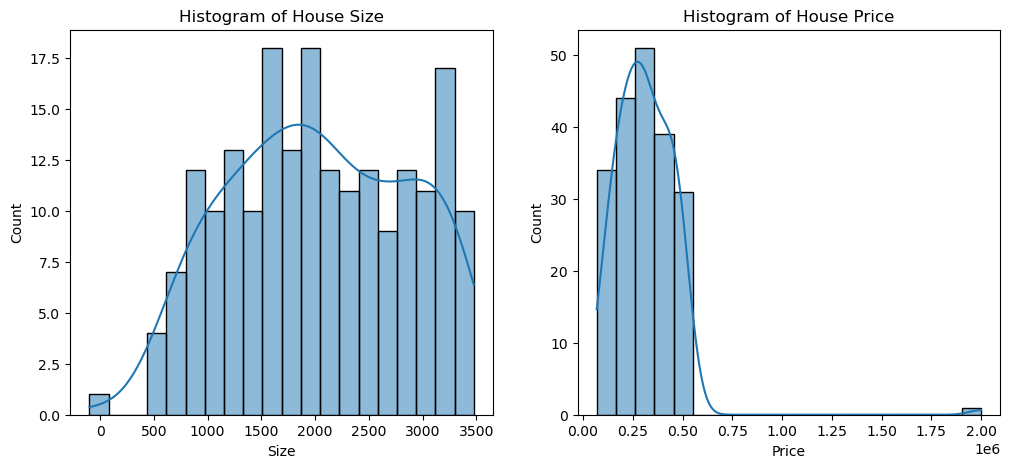

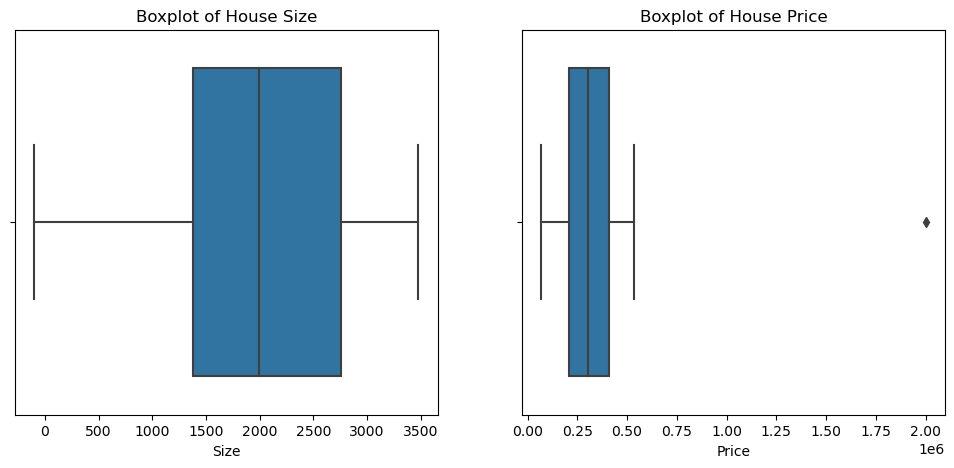

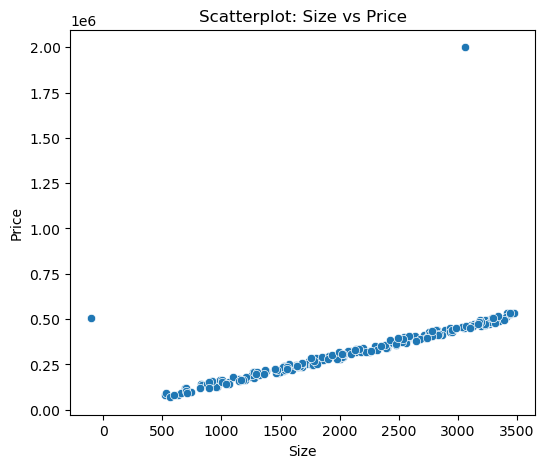


--- Interpretation of EDA ---
1. Histograms: Show distribution. Some missing values cause small gaps. Price is skewed due to outlier (2000000).
2. Boxplots: Extreme outlier clearly visible in Price. Negative Size also visible as outlier.
3. Scatterplot: General positive linear trend, but disturbed by outliers and missing/invalid values.


In [32]:
# =============================
# Step 3: EDA – Visualizations
# =============================
# Histograms
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Size'], bins=20, kde=True)
plt.title("Histogram of House Size")
plt.subplot(1,2,2)
sns.histplot(df['Price'], bins=20, kde=True)
plt.title("Histogram of House Price")
plt.show()

# Boxplots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x=df['Size'])
plt.title("Boxplot of House Size")
plt.subplot(1,2,2)
sns.boxplot(x=df['Price'])
plt.title("Boxplot of House Price")
plt.show()

# Scatterplot
plt.figure(figsize=(6,5))
sns.scatterplot(x='Size', y='Price', data=df)
plt.title("Scatterplot: Size vs Price")
plt.show()

# =============================
# Step 4: Interpret EDA (for teaching)
# =============================
print("\n--- Interpretation of EDA ---")
print("1. Histograms: Show distribution. Some missing values cause small gaps. Price is skewed due to outlier (2000000).")
print("2. Boxplots: Extreme outlier clearly visible in Price. Negative Size also visible as outlier.")
print("3. Scatterplot: General positive linear trend, but disturbed by outliers and missing/invalid values.")

In [33]:
# =============================
# Step 5: Data Cleaning
# =============================
df_clean = df.copy()

# Handle missing values → impute with median
df_clean['Size'].fillna(df_clean['Size'].median(), inplace=True)
df_clean['Price'].fillna(df_clean['Price'].median(), inplace=True)

# Remove duplicates
df_clean.drop_duplicates(inplace=True)

# Remove negative/invalid sizes
df_clean = df_clean[df_clean['Size'] > 0]

# Remove extreme outliers using IQR
Q1 = df_clean['Price'].quantile(0.25)
Q3 = df_clean['Price'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df_clean[(df_clean['Price'] >= Q1 - 1.5*IQR) & (df_clean['Price'] <= Q3 + 1.5*IQR)]

print("\nData after Cleaning:")
print(df_clean.head())


Data after Cleaning:
     Size     Price
0  1360.0  201675.0
1  1794.0  273038.0
2  1630.0  248164.0
3  1595.0  220886.0
4  2138.0  320780.0


In [34]:
### Save the data 
# Save DataFrame to CSV
df_clean.to_csv("df_clean.csv", index=False)


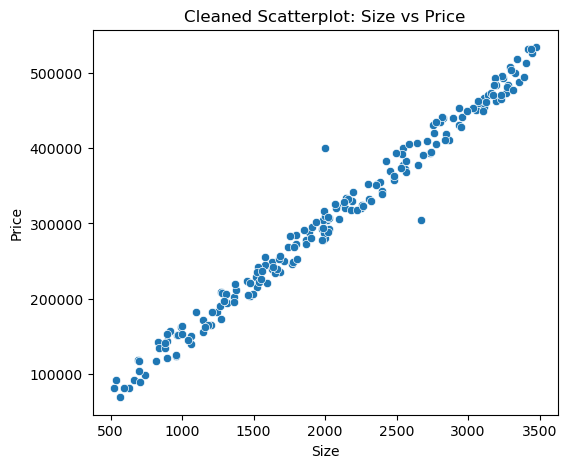


--- Interpretation ---
After cleaning, the scatterplot shows a clearer linear relationship without extreme noise/outliers.


In [35]:
# =============================
# Step 6: EDA after Cleaning
# =============================
plt.figure(figsize=(6,5))
sns.scatterplot(x='Size', y='Price', data=df_clean)
plt.title("Cleaned Scatterplot: Size vs Price")
plt.show()

print("\n--- Interpretation ---")
print("After cleaning, the scatterplot shows a clearer linear relationship without extreme noise/outliers.")

In [36]:
# =============================
# Step 7: Build Linear Regression Model
# =============================
X = df_clean[['Size']]
y = df_clean['Price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n--- Model Performance ---")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")


--- Model Performance ---
R² Score: 0.9892
MSE: 160850117.60
RMSE: 12682.67
Coefficient (Slope): 149.64
Intercept: -871.11


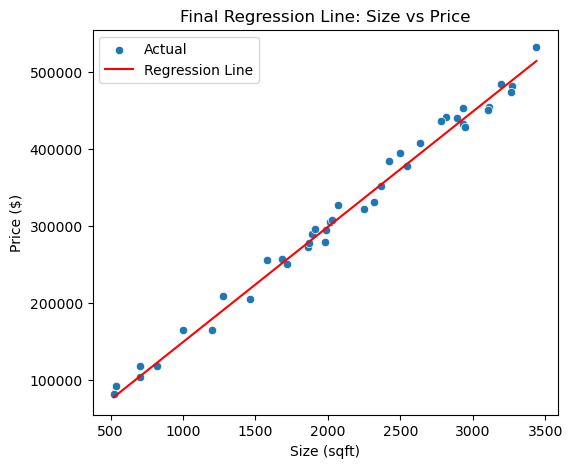

In [37]:
# =============================
# Step 8: Plot Regression Line
# =============================
plt.figure(figsize=(6,5))
sns.scatterplot(x=X_test['Size'], y=y_test, label="Actual")
sns.lineplot(x=X_test['Size'], y=y_pred, color="red", label="Regression Line")
plt.title("Final Regression Line: Size vs Price")
plt.xlabel("Size (sqft)")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

In [38]:
# =============================
# Step 9: Interpretation
# =============================
print("\n--- Final Interpretation ---")
print("1. The regression line fits the cleaned data well.")
print("2. Positive slope confirms that larger houses have higher prices.")
print("3. R² close to 1 indicates strong linear relationship.")
print("4. RMSE/MSE values show prediction error magnitude.")


--- Final Interpretation ---
1. The regression line fits the cleaned data well.
2. Positive slope confirms that larger houses have higher prices.
3. R² close to 1 indicates strong linear relationship.
4. RMSE/MSE values show prediction error magnitude.


#### Multiple Linear Regression

In [2]:
df_multi = pd.read_csv("house_price_multiple_linear.csv")

In [3]:
df_multi.head()

,Size,Rooms,Income,Price
0,1360.0,4,9806,315144.0
1,1794.0,4,2154,296060.0
2,1630.0,6,12729,394816.0
3,1595.0,7,3409,342428.0
4,2138.0,2,14249,399440.0


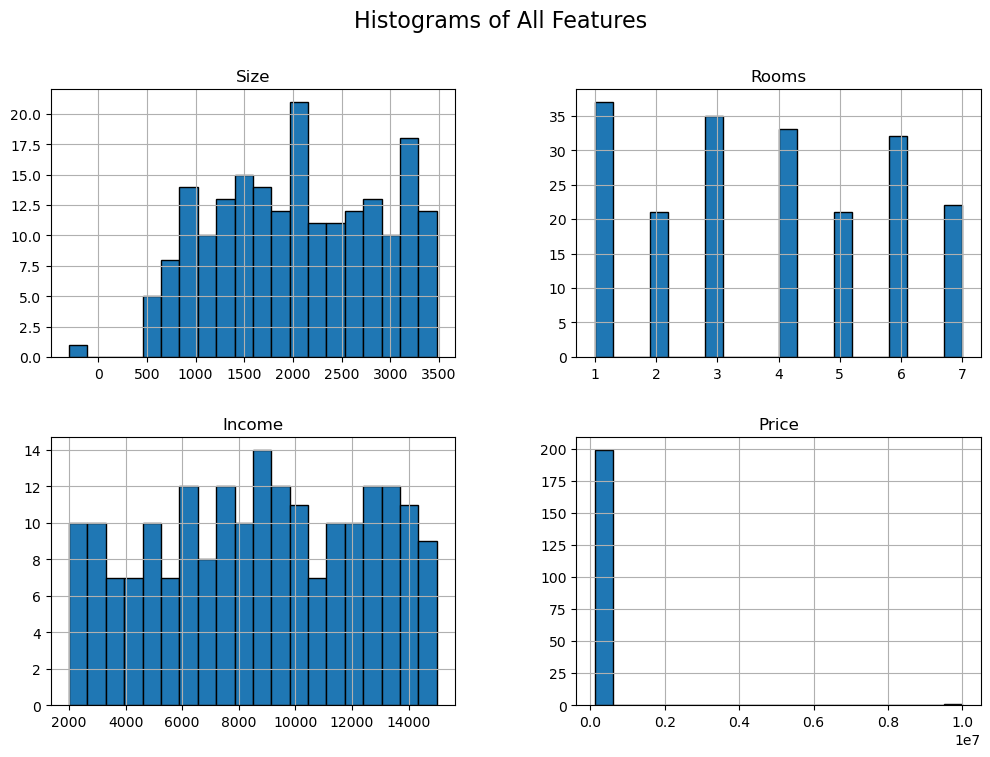

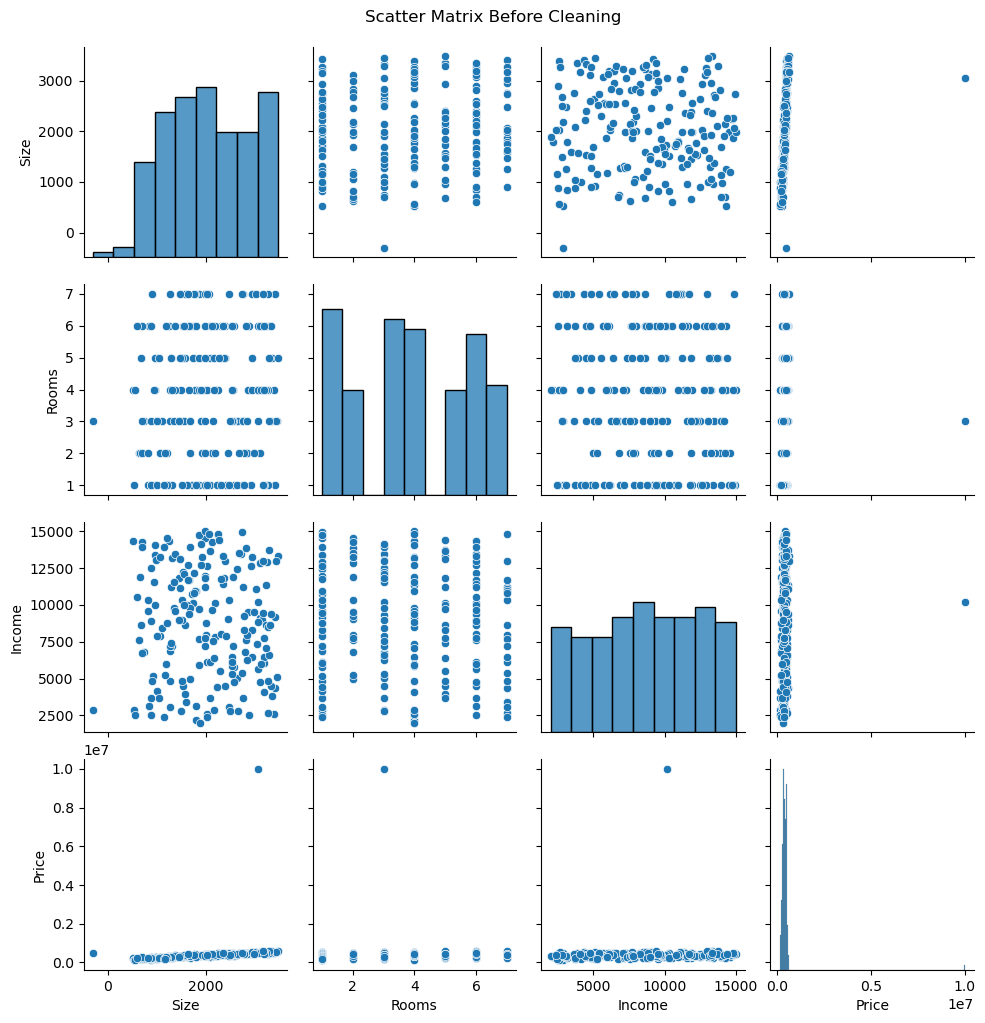

In [26]:
# ============================================
# Step 4: EDA – Initial Visualization
# ============================================
df_multi.hist(figsize=(12,8), bins=20, edgecolor="black")
plt.suptitle("Histograms of All Features", fontsize=16)
plt.show()

sns.pairplot(df_multi)
plt.suptitle("Scatter Matrix Before Cleaning", y=1.02)
plt.show()

In [19]:
# ============================================
# Step 5: Data Cleaning
# ============================================
df_clean = df_multi.copy()

# Fill missing values with median
df_clean['Size'].fillna(df_clean['Size'].median(), inplace=True)
df_clean['Price'].fillna(df_clean['Price'].median(), inplace=True)

# Remove duplicates
df_clean.drop_duplicates(inplace=True)

# Remove invalid negative Size
df_clean = df_clean[df_clean['Size'] > 0]

# Handle outliers in Price using IQR
Q1, Q3 = df_clean['Price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df_clean = df_clean[(df_clean['Price'] >= low) & (df_clean['Price'] <= high)]

print("\nData After Cleaning:")
print(df_clean.head())


Data After Cleaning:
     Size  Rooms  Income     Price
0  1360.0      4    9806  315144.0
1  1794.0      4    2154  296060.0
2  1630.0      6   12729  394816.0
3  1595.0      7    3409  342428.0
4  2138.0      2   14249  399440.0


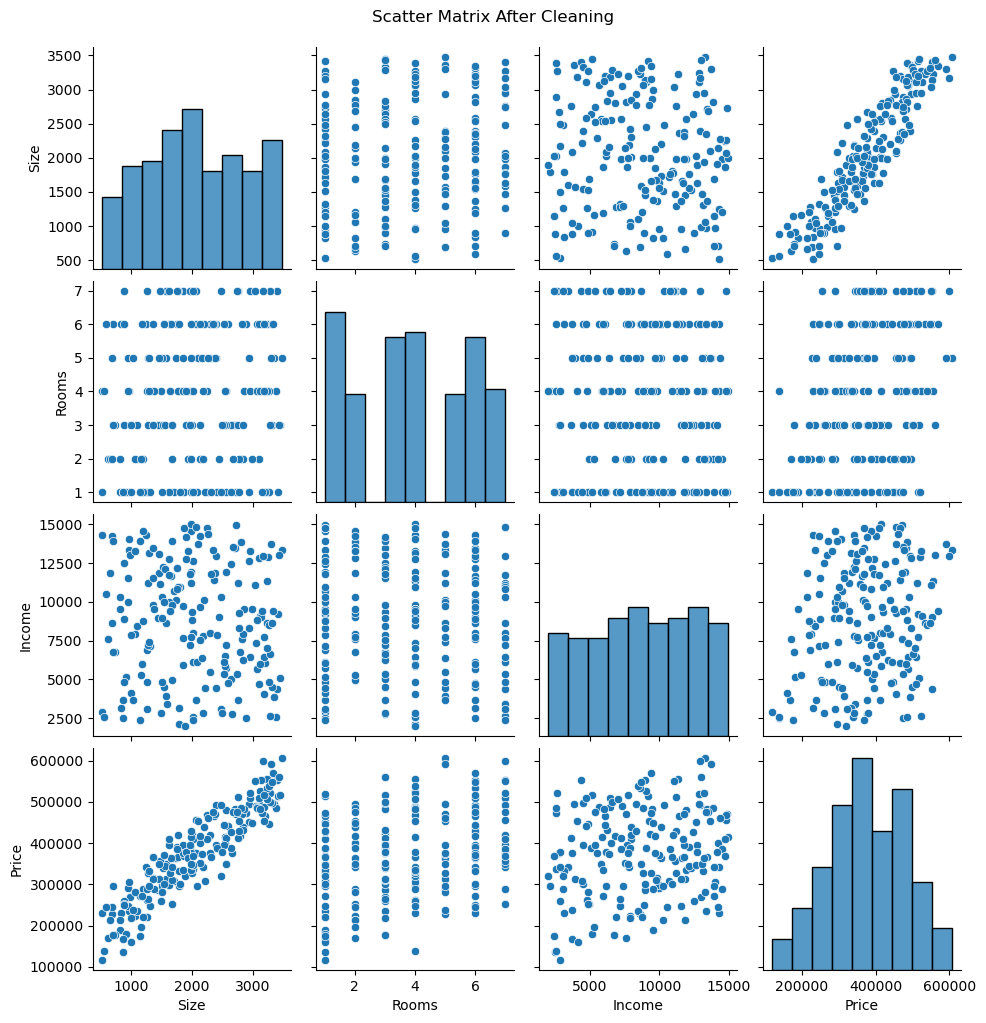

In [27]:
# ============================================
# Step 6: EDA After Cleaning
# ============================================
sns.pairplot(df_clean)
plt.suptitle("Scatter Matrix After Cleaning", y=1.02)
plt.show()

In [21]:
# ============================================
# Step 7: Build Multiple Linear Regression Model
# ============================================
X = df_clean[['Size','Rooms','Income']]
y = df_clean['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n--- Model Performance ---")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print("\nCoefficients:")
print(f"Size: {model.coef_[0]:.2f}")
print(f"Rooms: {model.coef_[1]:.2f}")
print(f"Income: {model.coef_[2]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")


--- Model Performance ---
R² Score: 0.9860
MSE: 163020406.31
RMSE: 12767.94

Coefficients:
Size: 120.09
Rooms: 14517.77
Income: 8.53
Intercept: -2117.84


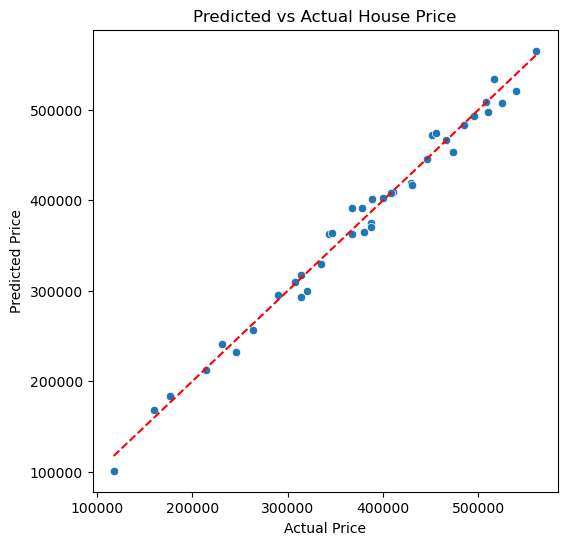

In [22]:
# ============================================
# Step 8: Predicted vs Actual Plot
# ============================================
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual House Price")
plt.show()

In [23]:
# ============================================
# Step 9: Interpretation (teaching points)
# ============================================
print("\n--- Final Interpretation ---")
print("1. R² shows how well model explains variation in Price.")
print("2. Coefficients explain contribution of each feature:")
print("   - Size: larger houses increase price.")
print("   - Rooms: more rooms increase price significantly.")
print("   - Income: higher buyer income pushes price up.")
print("3. Predicted vs Actual scatter shows good model alignment after cleaning.")


--- Final Interpretation ---
1. R² shows how well model explains variation in Price.
2. Coefficients explain contribution of each feature:
   - Size: larger houses increase price.
   - Rooms: more rooms increase price significantly.
   - Income: higher buyer income pushes price up.
3. Predicted vs Actual scatter shows good model alignment after cleaning.
